# 2D Sound Baseline v0.4

Category: `training`

Purpose:
Test whether the current validated 2-channel 2D representation (`normalized_window` + `active_mask`) produces useful signal on a controlled pump subset while emitting a self-describing training run record.

Inputs:
- tracked export manifests from `preprocessing/03.training-export/output/manifests/`
- local tensor exports under `training-data/`
- fixed baseline architecture `Baseline2DCNN`

Outputs:
- canonical run artifacts in `models/<run_id>/`
- `run_manifest.json`
- `training_history.json`
- `metrics.json`
- `split_membership.csv`
- `model_card.md`
- optional local-only checkpoints (`.pt`), intentionally excluded from Git

Decision supported:
- `READY_FOR_NEXT_DECISION` if the pipeline, metadata capture, and training run complete cleanly
- `PATCH_REQUIRED` otherwise


## 1. Imports and repo-root detection


In [1]:
from pathlib import Path
from typing import Sequence
from datetime import datetime, timezone
import hashlib
import json
import platform
import random
import re
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

try:
    import torchaudio
except Exception:
    torchaudio = None

try:
    import pyarrow
except Exception:
    pyarrow = None

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    from sklearn.metrics import classification_report
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'train').exists() and (candidate / 'preprocessing').exists():
            return candidate
    raise RuntimeError('Could not locate repo root containing train/ and preprocessing/.')


REPO_ROOT = find_repo_root(Path.cwd())
print(f'Using repo root: {REPO_ROOT}')


def repo_rel(path_value) -> str:
    path = Path(path_value).expanduser().resolve()
    try:
        return path.relative_to(REPO_ROOT).as_posix()
    except Exception:
        return str(path)


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path_value) -> str | None:
    path = Path(path_value)
    if not path.exists() or not path.is_file():
        return None
    digest = hashlib.sha256()
    with path.open('rb') as fh:
        for chunk in iter(lambda: fh.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


Using repo root: /home/mitch/development/raccoon-ball


## 2. Configuration


In [2]:
NOTEBOOK_RELATIVE_PATH = Path('train/2d-cnn/notebooks/2d_sound_v0.5.ipynb')
NOTEBOOK_PATH = REPO_ROOT / NOTEBOOK_RELATIVE_PATH

MANIFEST_ROOT = REPO_ROOT / 'preprocessing' / '03.training-export' / 'output' / 'manifests'

window_manifest_paths = [
    MANIFEST_ROOT / '20260319_152022_windows.parquet',
    MANIFEST_ROOT / '20260319_155015_windows.parquet',
]
clip_manifest_paths = [
    MANIFEST_ROOT / '20260319_152022_files.parquet',
    MANIFEST_ROOT / '20260319_155015_files.parquet',
]
preprocessing_config_paths = [
    MANIFEST_ROOT / '20260319_152022_config.json',
    MANIFEST_ROOT / '20260319_155015_config.json',
]

training_data_root = REPO_ROOT / 'training-data'
models_root = REPO_ROOT / 'models'

machine_filter = 'pump'

max_normal_clips = 1200
max_abnormal_clips = 1200
match_normal_to_abnormal_when_abnormal_limited = True
val_fraction = 0.2

batch_size = 32
num_epochs = 256
learning_rate = 5e-4
requested_device = 'cuda' if torch.cuda.is_available() else 'cpu'

random_seed = 42
deterministic_training = True

input_mode = 'normalized_plus_mask'
save_local_checkpoints = True

clip_aggregation_method = 'probability_mean'
if clip_aggregation_method not in {'probability_mean', 'majority_vote'}:
    raise ValueError(
        f'Unsupported clip_aggregation_method={clip_aggregation_method}. '
        "Use 'probability_mean' or 'majority_vote'."
    )

change_note = (
    'v0.5 clip-level validation extension: keep window-level training/eval intact, '
    'add clip-level aggregation/metrics/artifacts (probability_mean default, majority_vote optional).'
)

np.random.seed(random_seed)
random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)
if hasattr(torch.backends, 'cudnn'):
    torch.backends.cudnn.deterministic = bool(deterministic_training)
    torch.backends.cudnn.benchmark = not bool(deterministic_training)

if not NOTEBOOK_PATH.exists():
    raise FileNotFoundError(f'Notebook path does not exist: {NOTEBOOK_PATH}')

for required_path in [*window_manifest_paths, *clip_manifest_paths, *preprocessing_config_paths]:
    if not required_path.exists():
        raise FileNotFoundError(f'Required input path not found: {required_path}')

CHECKS = {
    'manifests loaded': False,
    'clip-level split applied': False,
    'split diagnostics printed': False,
    'dataset loader works': False,
    'training completed': False,
    'prediction distribution computed': False,
    'confusion matrix generated': False,
    'clip-level metrics computed': False,
    'history plots generated': False,
    'split membership saved': False,
    'metrics artifact saved': False,
    'clip-level artifacts saved': False,
    'run manifest saved': False,
    'model artifacts saved': False,
}

NAN_DETECTED = False
TRAINING_EXCEPTION = None

best_val_loss = float('inf')
best_epoch = None
best_state_dict = None
best_clip_acc = None
best_clip_metrics = None

MODEL_OUTPUT_DIR = None
FINAL_MODEL_PATH = None
BEST_MODEL_PATH = None
TRAINING_HISTORY_JSON_PATH = None
METRICS_JSON_PATH = None
RUN_MANIFEST_JSON_PATH = None
SPLIT_MEMBERSHIP_PATH = None
CLIP_LEVEL_SUMMARY_CSV_PATH = None
CLIP_LEVEL_SUMMARY_JSON_PATH = None
MODEL_CARD_PATH = None

print('Configuration loaded.')
print(f'notebook={NOTEBOOK_RELATIVE_PATH.as_posix()}')
print(f'input_mode={input_mode}')
print(f'requested_device={requested_device}, batch_size={batch_size}, num_epochs={num_epochs}, lr={learning_rate}')
print(f'clip_aggregation_method={clip_aggregation_method}')
print('window manifests:')
for path in window_manifest_paths:
    print(' -', repo_rel(path))
print('clip manifests:')
for path in clip_manifest_paths:
    print(' -', repo_rel(path))


Configuration loaded.
notebook=train/2d-cnn/notebooks/2d_sound_v0.5.ipynb
input_mode=normalized_plus_mask
requested_device=cuda, batch_size=32, num_epochs=256, lr=0.0005
clip_aggregation_method=probability_mean
window manifests:
 - preprocessing/03.training-export/output/manifests/20260319_152022_windows.parquet
 - preprocessing/03.training-export/output/manifests/20260319_155015_windows.parquet
clip manifests:
 - preprocessing/03.training-export/output/manifests/20260319_152022_files.parquet
 - preprocessing/03.training-export/output/manifests/20260319_155015_files.parquet


## 3. Manifest loading and clip-level split


In [3]:
def _to_path_list(value):
    if isinstance(value, (str, Path)):
        raw = [value]
    elif isinstance(value, Sequence):
        raw = list(value)
    else:
        raise TypeError(f'Expected Path/str or a sequence of paths, got {type(value)}')

    out = []
    for v in raw:
        p = Path(v).expanduser()
        if not p.is_absolute():
            p = (REPO_ROOT / p).resolve()
        else:
            p = p.resolve()
        out.append(p)
    return out


def _read_parquet_many(paths, kind_name):
    dfs = []
    for p in paths:
        if not p.exists():
            raise FileNotFoundError(f'{kind_name} manifest not found: {p}')
        try:
            df = pd.read_parquet(p)
        except Exception as exc:
            raise RuntimeError(
                f'Failed to read {kind_name} parquet at {p}. Ensure pyarrow/fastparquet is installed.'
            ) from exc
        df = df.copy()
        df['_manifest_path'] = repo_rel(p)
        dfs.append(df)

    if not dfs:
        raise RuntimeError(f'No {kind_name} manifests provided.')
    return pd.concat(dfs, ignore_index=True)


def _pick_first_column(df, candidates, required=True, purpose=''):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f'Could not find required column for {purpose}. Tried: {candidates}. Available: {list(df.columns)}'
        )
    return None


def _normalize_path_str(x):
    return str(x).replace('\\', '/')


def _resolve_npz_path(path_value):
    p = Path(str(path_value)).expanduser()
    candidates = []

    if p.is_absolute():
        candidates.append(p.resolve())
    else:
        candidates.append((REPO_ROOT / p).resolve())
        candidates.append((training_data_root / p).resolve())
        candidates.append((training_data_root / 'tensors' / p).resolve())

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def _label_from_text(text):
    t = str(text).lower()
    if ('abnormal' in t) or ('-ab-' in t) or re.search(r'(^|[-_/])ab($|[-_/])', t):
        return 1
    if ('normal' in t) or ('-nm-' in t) or re.search(r'(^|[-_/])nm($|[-_/])', t):
        return 0
    return None


def _infer_label(row, explicit_label_col, text_cols):
    if explicit_label_col is not None:
        v = row.get(explicit_label_col)
        if pd.notna(v):
            token = str(v).strip().lower()
            if token in {'normal', 'nm', '0', 'false', 'non_anomalous', 'non-anomalous'}:
                return 0
            if token in {'abnormal', 'ab', '1', 'true', 'anomalous', 'anomaly'}:
                return 1

    for c in text_cols:
        if c in row and pd.notna(row[c]):
            parsed = _label_from_text(row[c])
            if parsed is not None:
                return parsed
    return None


def _infer_machine(row, explicit_machine_col, text_cols):
    if explicit_machine_col is not None:
        v = row.get(explicit_machine_col)
        if pd.notna(v):
            return str(v).strip().lower()

    text = ' '.join(str(row[c]) for c in text_cols if c in row and pd.notna(row[c])).lower()
    for token in ['pump', 'fan', 'slider', 'valve']:
        if re.search(rf'(^|[-_/]){token}($|[-_/])', text) or token in text:
            return token
    return None


def _infer_db_level(row, text_cols):
    text = ' '.join(str(row[c]) for c in text_cols if c in row and pd.notna(row[c])).lower()
    match = re.search(r'([+-]?\d+)db', text)
    if match:
        return int(match.group(1))
    match = re.search(r'([+-]\d+)-', text)
    if match:
        return int(match.group(1))
    return None


def _split_clip_ids(ids, val_fraction_local=0.2, seed=42):
    ids = list(dict.fromkeys([str(x) for x in ids]))
    if len(ids) == 0:
        return [], []

    rng = np.random.default_rng(seed)
    rng.shuffle(ids)

    if len(ids) < 2:
        return ids, []

    n_val = int(round(len(ids) * val_fraction_local))
    n_val = max(1, min(n_val, len(ids) - 1))
    val_ids = ids[:n_val]
    train_ids = ids[n_val:]
    return train_ids, val_ids


def _validate_window_manifest_alignment(windows_subset_df: pd.DataFrame, subset_name: str = 'window subset'):
    required_cols = {'npz_path', 'tensor_index'}
    missing = sorted(required_cols - set(windows_subset_df.columns))
    if missing:
        raise RuntimeError(f'{subset_name} is missing required columns for alignment check: {missing}')

    count_mismatches = []
    index_mismatches = []

    for npz_path_value, group in windows_subset_df.groupby('npz_path', sort=False):
        npz_path = Path(str(npz_path_value))
        if not npz_path.exists():
            raise FileNotFoundError(f'NPZ referenced by {subset_name} does not exist: {npz_path}')

        with np.load(npz_path, allow_pickle=False) as npz:
            if 'normalized_window' not in npz.files or 'active_mask' not in npz.files:
                raise KeyError(
                    f'NPZ referenced by {subset_name} is missing required arrays: {npz_path}. '
                    "Expected keys: 'normalized_window' and 'active_mask'."
                )
            n_normalized = int(npz['normalized_window'].shape[0])
            n_mask = int(npz['active_mask'].shape[0])

        manifest_count = int(len(group))
        if manifest_count != n_normalized or n_normalized != n_mask:
            count_mismatches.append((str(npz_path), manifest_count, n_normalized, n_mask))

        tensor_indices = sorted(group['tensor_index'].astype(int).tolist())
        expected_indices = list(range(len(tensor_indices)))
        if tensor_indices != expected_indices:
            index_mismatches.append((str(npz_path), tensor_indices[:5], tensor_indices[-5:], len(tensor_indices)))

    if count_mismatches:
        preview = '; '.join(
            [f'{p} manifest={m}, normalized_window={n}, active_mask={a}' for p, m, n, a in count_mismatches[:5]]
        )
        raise RuntimeError(
            f'Window/manifest row-count alignment failed for {subset_name}. '
            f'First mismatches: {preview}'
        )

    if index_mismatches:
        preview = '; '.join(
            [f'{p} first={fst}, last={lst}, count={cnt}' for p, fst, lst, cnt in index_mismatches[:5]]
        )
        raise RuntimeError(
            f'Window tensor_index alignment failed for {subset_name}. '
            f'Expected contiguous 0..N-1 per npz. First mismatches: {preview}'
        )

    return {
        'checked_npz_files': int(windows_subset_df['npz_path'].nunique()),
        'checked_window_rows': int(len(windows_subset_df)),
    }


window_df = _read_parquet_many(_to_path_list(window_manifest_paths), 'window')
clip_df = _read_parquet_many(_to_path_list(clip_manifest_paths), 'clip')

if 'status' in clip_df.columns:
    clip_df = clip_df[clip_df['status'].isin(['exported', 'skipped_existing'])].copy()

if window_df.empty or clip_df.empty:
    raise RuntimeError('Window or clip manifest is empty after loading/filtering.')

clip_npz_col = _pick_first_column(
    clip_df,
    ['tensor_npz_path', 'npz_path', 'tensor_path', 'npz', 'path'],
    required=True,
    purpose='clip npz path',
)
window_npz_col = _pick_first_column(
    window_df,
    ['tensor_npz_path', 'npz_path', 'tensor_path', 'npz', 'path'],
    required=True,
    purpose='window npz path',
)
tensor_index_col = _pick_first_column(
    window_df,
    ['tensor_index', 'window_index'],
    required=True,
    purpose='window tensor index',
)

clip_df = clip_df.copy()
window_df = window_df.copy()

clip_df['tensor_npz_path'] = clip_df[clip_npz_col].map(lambda x: str(_resolve_npz_path(x)))
window_df['npz_path'] = window_df[window_npz_col].map(lambda x: str(_resolve_npz_path(x)))
clip_df['_npz_norm'] = clip_df['tensor_npz_path'].map(_normalize_path_str)
window_df['_npz_norm'] = window_df['npz_path'].map(_normalize_path_str)
window_df['tensor_index'] = window_df[tensor_index_col].astype(int)
window_df['window_manifest_path'] = window_df['_manifest_path']

relative_source_col = _pick_first_column(clip_df, ['relative_source_path'], required=False, purpose='relative source path')
source_file_col = _pick_first_column(clip_df, ['source_file'], required=False, purpose='source file')
clip_id_col = _pick_first_column(
    clip_df,
    ['original_clip_id', 'source_clip_id', 'clip_id'],
    required=False,
    purpose='original clip id',
)

if relative_source_col is not None:
    clip_df['relative_source_path'] = clip_df[relative_source_col].astype(str)
elif source_file_col is not None:
    clip_df['relative_source_path'] = clip_df[source_file_col].astype(str)
else:
    clip_df['relative_source_path'] = clip_df['tensor_npz_path'].map(lambda x: Path(str(x)).with_suffix('.wav').as_posix())

if source_file_col is not None:
    clip_df['source_file'] = clip_df[source_file_col].astype(str)
else:
    clip_df['source_file'] = clip_df['relative_source_path']

clip_df['clip_manifest_path'] = clip_df['_manifest_path']
if clip_id_col is not None:
    clip_df['clip_id'] = clip_df[clip_id_col].astype(str)
    clip_id_source_field = clip_id_col
elif relative_source_col is not None:
    clip_df['clip_id'] = clip_df['relative_source_path'].astype(str)
    clip_id_source_field = 'relative_source_path'
elif source_file_col is not None:
    clip_df['clip_id'] = clip_df['source_file'].astype(str)
    clip_id_source_field = 'source_file'
else:
    clip_df['clip_id'] = clip_df['tensor_npz_path'].map(lambda x: Path(str(x)).with_suffix('.wav').as_posix())
    clip_id_source_field = 'tensor_npz_path (fallback-derived)'

clip_df['clip_id'] = clip_df['clip_id'].map(_normalize_path_str).map(lambda x: str(x).strip())
missing_clip_id_mask = clip_df['clip_id'].eq('') | clip_df['clip_id'].str.lower().eq('nan')
if missing_clip_id_mask.any():
    sample_cols = [c for c in ['tensor_npz_path', 'relative_source_path', 'source_file'] if c in clip_df.columns]
    examples = clip_df.loc[missing_clip_id_mask, sample_cols].head(5)
    raise RuntimeError('Clip id resolution failed: at least one clip has an empty clip_id. Example rows: ' + examples.to_string(index=False))

clip_id_to_npz_count = clip_df.groupby('clip_id')['_npz_norm'].nunique()
clip_id_collision = clip_id_to_npz_count[clip_id_to_npz_count > 1]
if not clip_id_collision.empty:
    raise RuntimeError(
        'Clip id collision detected: one clip_id maps to multiple tensor_npz_path entries. '
        f'Examples: {clip_id_collision.head(10).to_dict()}'
    )

npz_to_clip_id_count = clip_df.groupby('_npz_norm')['clip_id'].nunique()
npz_collision = npz_to_clip_id_count[npz_to_clip_id_count > 1]
if not npz_collision.empty:
    raise RuntimeError(
        'Manifest consistency error: one tensor_npz_path maps to multiple clip_id values. '
        f'Examples: {npz_collision.head(10).to_dict()}'
    )

label_col = _pick_first_column(
    clip_df,
    ['label', 'class_label', 'class', 'target', 'condition', 'anomaly_label'],
    required=False,
    purpose='label',
)
machine_col = _pick_first_column(
    clip_df,
    ['machine', 'machine_type', 'machine_name'],
    required=False,
    purpose='machine',
)

text_cols_for_inference = [
    c for c in ['source_file', 'relative_source_path', 'tensor_npz_path'] if c in clip_df.columns
]
clip_df['label'] = clip_df.apply(lambda r: _infer_label(r, label_col, text_cols_for_inference), axis=1)
clip_df['machine'] = clip_df.apply(lambda r: _infer_machine(r, machine_col, text_cols_for_inference), axis=1)
clip_df['db_level'] = clip_df.apply(lambda r: _infer_db_level(r, text_cols_for_inference), axis=1)

missing_label_mask = clip_df['label'].isna()
if missing_label_mask.any():
    examples = clip_df.loc[missing_label_mask, text_cols_for_inference].head(5)
    msg = (
        'Could not infer normal/abnormal label for some clips. '
        'Please add a label column or use path naming containing normal/abnormal or -nm-/-ab-.'
    )
    raise RuntimeError(msg + ' Example rows: ' + examples.to_string(index=False))

clip_df['label'] = clip_df['label'].astype(int)
clip_df['condition'] = clip_df['label'].map({0: 'normal', 1: 'abnormal'})

if machine_filter:
    mf = str(machine_filter).strip().lower()
    clip_df = clip_df[clip_df['machine'].fillna('').str.contains(mf, regex=False)].copy()

normal_candidates = clip_df[clip_df['label'] == 0].drop_duplicates('_npz_norm').sort_values('clip_id')
abnormal_candidates = clip_df[clip_df['label'] == 1].drop_duplicates('_npz_norm').sort_values('clip_id')

selected_abnormal_df = abnormal_candidates.head(max_abnormal_clips).copy()
if selected_abnormal_df.empty:
    raise RuntimeError('No abnormal clips were selected. Check manifests/filtering.')

if match_normal_to_abnormal_when_abnormal_limited and len(selected_abnormal_df) < max_abnormal_clips:
    target_normal_count = min(max_normal_clips, len(selected_abnormal_df))
else:
    target_normal_count = max_normal_clips

selected_normal_df = normal_candidates.head(target_normal_count).copy()
if selected_normal_df.empty:
    raise RuntimeError('No normal clips were selected. Check manifests/filtering.')

selected_clips_df = pd.concat([selected_normal_df, selected_abnormal_df], ignore_index=True)

selected_lookup = selected_clips_df[
    ['_npz_norm', 'tensor_npz_path', 'clip_id', 'label', 'machine', 'db_level', 'condition',
     'clip_manifest_path', 'relative_source_path', 'source_file']
].drop_duplicates('_npz_norm')

selected_windows_df = window_df.merge(selected_lookup, on='_npz_norm', how='inner', suffixes=('_window', '_clip'))
if selected_windows_df.empty:
    raise RuntimeError('Selected subset produced zero window rows. Check manifest alignment.')

alignment_stats = _validate_window_manifest_alignment(selected_windows_df, subset_name='selected windows')

per_clip_label_counts = selected_windows_df.groupby('clip_id')['label'].nunique(dropna=False)
if (per_clip_label_counts > 1).any():
    bad = per_clip_label_counts[per_clip_label_counts > 1].head(10)
    raise RuntimeError(
        'Clip label consistency failed: at least one clip_id has multiple labels. '
        f'Examples: {bad.to_dict()}'
    )

train_clip_ids = []
val_clip_ids = []
for label_value in [0, 1]:
    class_clip_ids = selected_clips_df.loc[selected_clips_df['label'] == label_value, 'clip_id'].astype(str).tolist()
    tr_ids, va_ids = _split_clip_ids(class_clip_ids, val_fraction_local=val_fraction, seed=random_seed + label_value)
    train_clip_ids.extend(tr_ids)
    val_clip_ids.extend(va_ids)

if len(train_clip_ids) == 0 or len(val_clip_ids) == 0:
    raise RuntimeError(
        'Clip split produced an empty train or validation split. '
        'Increase selected clips so each class has at least two clips.'
    )

if set(train_clip_ids).intersection(set(val_clip_ids)):
    raise RuntimeError('Clip leakage detected: at least one clip appears in both train and validation.')

train_windows_df = selected_windows_df[selected_windows_df['clip_id'].astype(str).isin(train_clip_ids)].copy()
val_windows_df = selected_windows_df[selected_windows_df['clip_id'].astype(str).isin(val_clip_ids)].copy()

if train_windows_df.empty or val_windows_df.empty:
    raise RuntimeError('Train or validation window set is empty after clip-level split.')

split_membership_df = selected_clips_df[
    ['clip_id', 'label', 'machine', 'db_level', 'condition', 'relative_source_path', 'source_file',
     'tensor_npz_path', 'clip_manifest_path']
].copy()
split_membership_df['split'] = split_membership_df['clip_id'].map(
    lambda clip_id: 'train' if str(clip_id) in set(train_clip_ids) else 'validation'
)
split_membership_df['label_name'] = split_membership_df['label'].map({0: 'normal', 1: 'abnormal'})
split_membership_df = split_membership_df[
    ['clip_id', 'split', 'label', 'label_name', 'machine', 'db_level', 'condition',
     'relative_source_path', 'source_file', 'tensor_npz_path', 'clip_manifest_path']
].sort_values(['split', 'label', 'clip_id']).reset_index(drop=True)

CHECKS['manifests loaded'] = True
CHECKS['clip-level split applied'] = True

print(f'Loaded window rows: {len(window_df):,}')
print(f'Loaded clip rows: {len(clip_df):,}')
print(f'Clip id source field: {clip_id_source_field}')
print(
    'Selected-window alignment check: '
    f"npz_files={alignment_stats['checked_npz_files']}, window_rows={alignment_stats['checked_window_rows']}"
)
print(f'Selected normal clips: {len(selected_normal_df)}')
print(f'Selected abnormal clips: {len(selected_abnormal_df)}')
print(f'Train clips: {len(train_clip_ids)} | Validation clips: {len(val_clip_ids)}')


Loaded window rows: 75,690
Loaded clip rows: 4,205
Clip id source field: relative_source_path
Selected-window alignment check: npz_files=912, window_rows=16416
Selected normal clips: 456
Selected abnormal clips: 456
Train clips: 730 | Validation clips: 182


## 4. Dataset loader and pre-training diagnostics


In [4]:
def _count_by_label(df, label_col='label'):
    vc = df[label_col].value_counts().sort_index()
    return int(vc.get(0, 0)), int(vc.get(1, 0))


class TwoChannelWindowDataset(Dataset):
    def __init__(self, rows_df: pd.DataFrame, input_mode_local: str = 'normalized_plus_mask', return_clip_id: bool = False):
        required_cols = {'npz_path', 'tensor_index', 'label', 'clip_id'}
        missing = sorted(required_cols - set(rows_df.columns))
        if missing:
            raise ValueError(f'Dataset rows are missing required columns: {missing}')

        if input_mode_local not in {'normalized_plus_mask', 'normalized_only'}:
            raise ValueError(f'Unsupported input_mode: {input_mode_local}')

        self.rows = rows_df[['npz_path', 'tensor_index', 'label', 'clip_id']].reset_index(drop=True).copy()
        self.input_mode = input_mode_local
        self.return_clip_id = bool(return_clip_id)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        npz_path = Path(str(row['npz_path']))
        tensor_index = int(row['tensor_index'])
        label = int(row['label'])
        clip_id = str(row['clip_id']).strip()

        if label not in (0, 1):
            raise ValueError(f'Invalid label at idx={idx}: {label}. Expected 0 (normal) or 1 (abnormal).')
        if not clip_id or clip_id.lower() == 'nan':
            raise ValueError(f'Missing clip_id at idx={idx}.')
        if not npz_path.exists():
            raise FileNotFoundError(f'NPZ not found at idx={idx}: {npz_path}')

        with np.load(npz_path, allow_pickle=False) as npz:
            if 'normalized_window' not in npz.files:
                raise KeyError(f"Missing key 'normalized_window' in {npz_path}")
            if 'active_mask' not in npz.files:
                raise KeyError(f"Missing key 'active_mask' in {npz_path}")

            normalized_all = npz['normalized_window']
            active_all = npz['active_mask']

            if tensor_index < 0 or tensor_index >= normalized_all.shape[0]:
                raise IndexError(
                    f'tensor_index out of bounds for {npz_path}: index={tensor_index}, N={normalized_all.shape[0]}'
                )

            normalized_window = normalized_all[tensor_index]
            active_mask = active_all[tensor_index]

        if normalized_window.shape != (96, 64):
            raise ValueError(
                f'normalized_window shape mismatch at idx={idx}: got {normalized_window.shape}, expected (96, 64)'
            )
        if active_mask.shape != (96, 64):
            raise ValueError(
                f'active_mask shape mismatch at idx={idx}: got {active_mask.shape}, expected (96, 64)'
            )

        channel_0 = normalized_window.astype(np.float32, copy=False)
        if self.input_mode == 'normalized_plus_mask':
            channel_1 = active_mask.astype(np.float32, copy=False)
        else:
            channel_1 = np.zeros_like(channel_0, dtype=np.float32)

        x = np.stack([channel_0, channel_1], axis=0)

        if x.shape != (2, 96, 64):
            raise ValueError(f'stacked tensor shape mismatch at idx={idx}: got {x.shape}, expected (2, 96, 64)')
        if x.dtype != np.float32:
            raise TypeError(f'stacked tensor dtype mismatch at idx={idx}: got {x.dtype}, expected float32')

        sample_x = torch.from_numpy(x)
        sample_y = torch.tensor(label, dtype=torch.long)
        if self.return_clip_id:
            return sample_x, sample_y, clip_id
        return sample_x, sample_y


train_dataset = TwoChannelWindowDataset(train_windows_df, input_mode_local=input_mode, return_clip_id=False)
val_dataset = TwoChannelWindowDataset(val_windows_df, input_mode_local=input_mode, return_clip_id=True)

train_generator = torch.Generator()
train_generator.manual_seed(random_seed)

pin_memory = (requested_device == 'cuda') and torch.cuda.is_available()
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
    generator=train_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

sample_x, sample_y = train_dataset[0]
batch_x, batch_y = next(iter(train_loader))
val_sample_x, val_sample_y, val_sample_clip_id = val_dataset[0]

train_clip_df = selected_clips_df[selected_clips_df['clip_id'].astype(str).isin(train_clip_ids)].copy()
val_clip_df = selected_clips_df[selected_clips_df['clip_id'].astype(str).isin(val_clip_ids)].copy()

train_normal_clips, train_abnormal_clips = _count_by_label(train_clip_df, label_col='label')
val_normal_clips, val_abnormal_clips = _count_by_label(val_clip_df, label_col='label')
train_normal_windows, train_abnormal_windows = _count_by_label(train_windows_df, label_col='label')
val_normal_windows, val_abnormal_windows = _count_by_label(val_windows_df, label_col='label')

def _balance_text(df):
    vc = df['label'].value_counts().sort_index()
    total = int(vc.sum()) if len(vc) else 0
    n0 = int(vc.get(0, 0))
    n1 = int(vc.get(1, 0))
    if total == 0:
        return 'normal=0 (0.00%), abnormal=0 (0.00%)'
    return f'normal={n0} ({100.0*n0/total:.2f}%), abnormal={n1} ({100.0*n1/total:.2f}%)'


print('1. split summary:')
print(f'   selected clips={len(selected_clips_df):,}, train clips={len(train_clip_ids):,}, validation clips={len(val_clip_ids):,}')
print('2. clip balance:')
print(f'   train clips: normal={train_normal_clips}, abnormal={train_abnormal_clips}')
print(f'   validation clips: normal={val_normal_clips}, abnormal={val_abnormal_clips}')
print('3. window balance:')
print('   train:', _balance_text(train_windows_df))
print('   validation:', _balance_text(val_windows_df))
print('4. one sample / batch checks:')
print('   single sample shape:', tuple(sample_x.shape))
print('   single sample dtype:', sample_x.dtype)
print('   single sample label:', int(sample_y))
print('   batch shape:', tuple(batch_x.shape))
print('   batch dtype:', batch_x.dtype)
print('   batch device:', batch_x.device)
print('   unique labels in one batch:', torch.unique(batch_y).tolist())
print('   validation sample clip_id:', val_sample_clip_id)
print('   validation sample label:', int(val_sample_y))

if not isinstance(val_sample_clip_id, str) or not val_sample_clip_id.strip():
    raise RuntimeError('Validation sample did not return a valid clip_id.')


display(split_membership_df.head(10))

CHECKS['dataset loader works'] = True
CHECKS['split diagnostics printed'] = True


1. split summary:
   selected clips=912, train clips=730, validation clips=182
2. clip balance:
   train clips: normal=365, abnormal=365
   validation clips: normal=91, abnormal=91
3. window balance:
   train: normal=6570 (50.00%), abnormal=6570 (50.00%)
   validation: normal=1638 (50.00%), abnormal=1638 (50.00%)
4. one sample / batch checks:
   single sample shape: (2, 96, 64)
   single sample dtype: torch.float32
   single sample label: 0
   batch shape: (32, 2, 96, 64)
   batch dtype: torch.float32
   batch device: cpu
   unique labels in one batch: [0, 1]
   validation sample clip_id: -6-pump-00-nm-0000.wav
   validation sample label: 0


,clip_id,split,label,label_name,machine,db_level,condition,relative_source_path,source_file,tensor_npz_path,clip_manifest_path
0,-6-pump-00-nm-0001.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0001.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
1,-6-pump-00-nm-0003.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0003.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
2,-6-pump-00-nm-0004.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0004.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
3,-6-pump-00-nm-0005.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0005.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
4,-6-pump-00-nm-0006.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0006.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
5,-6-pump-00-nm-0007.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0007.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
6,-6-pump-00-nm-0008.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0008.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
7,-6-pump-00-nm-0009.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0009.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
8,-6-pump-00-nm-0010.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0010.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...
9,-6-pump-00-nm-0011.wav,train,0,normal,pump,-6,normal,-6-pump-00-nm-0011.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,preprocessing/03.training-export/output/manife...


## 5. Model, optimization setup, and training loop


In [5]:
class Baseline2DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def _check_no_nan(name, tensor):
    global NAN_DETECTED
    if torch.isnan(tensor).any():
        NAN_DETECTED = True
        raise RuntimeError(f'NaN detected in {name}')


def _safe_div(a, b):
    return float(a) / float(b) if b else 0.0


def _confusion_matrix_binary(y_true, y_pred):
    cm = np.zeros((2, 2), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        if t in (0, 1) and p in (0, 1):
            cm[int(t), int(p)] += 1
    return cm


def _compute_clip_level_metrics_from_records(
    window_records,
    aggregation_method: str = 'probability_mean',
    include_report: bool = True,
):
    if aggregation_method not in {'probability_mean', 'majority_vote'}:
        raise ValueError(
            f'Unsupported aggregation_method={aggregation_method}. '
            "Use 'probability_mean' or 'majority_vote'."
        )

    if not window_records:
        raise RuntimeError('No validation window records were collected for clip-level evaluation.')

    records_df = pd.DataFrame(window_records).copy()
    required_cols = {'clip_id', 'true_label', 'pred_class', 'abnormal_prob'}
    missing_cols = sorted(required_cols - set(records_df.columns))
    if missing_cols:
        raise RuntimeError(f'Window records missing required fields: {missing_cols}')

    records_df['clip_id'] = records_df['clip_id'].astype(str)
    records_df['true_label'] = records_df['true_label'].astype(int)
    records_df['pred_class'] = records_df['pred_class'].astype(int)
    records_df['abnormal_prob'] = records_df['abnormal_prob'].astype(float)

    if records_df['clip_id'].isna().any() or records_df['clip_id'].str.strip().eq('').any():
        raise RuntimeError('clip_id exists check failed: at least one validation sample has empty clip_id.')

    per_clip_rows = []
    total_grouped_windows = 0

    for clip_id, group in records_df.groupby('clip_id', sort=True, dropna=False):
        num_windows = int(len(group))
        if num_windows < 1:
            raise RuntimeError(f'Clip {clip_id} has zero windows, which should be impossible.')

        total_grouped_windows += num_windows

        unique_labels = sorted(group['true_label'].unique().tolist())
        if len(unique_labels) != 1:
            raise RuntimeError(
                f'Clip {clip_id} has inconsistent labels across windows: {unique_labels}'
            )
        true_label = int(unique_labels[0])

        mean_abnormal_prob = float(group['abnormal_prob'].mean())
        mean_normal_prob = float(1.0 - mean_abnormal_prob)

        vote_normal = int((group['pred_class'] == 0).sum())
        vote_abnormal = int((group['pred_class'] == 1).sum())

        if vote_abnormal > vote_normal:
            majority_vote_pred = 1
        elif vote_normal > vote_abnormal:
            majority_vote_pred = 0
        else:
            majority_vote_pred = 1 if mean_abnormal_prob >= 0.5 else 0

        probability_mean_pred = 1 if mean_abnormal_prob >= 0.5 else 0

        per_clip_rows.append(
            {
                'clip_id': str(clip_id),
                'true_label': true_label,
                'num_windows': num_windows,
                'mean_abnormal_prob': mean_abnormal_prob,
                'mean_normal_prob': mean_normal_prob,
                'majority_vote_pred': int(majority_vote_pred),
                'probability_mean_pred': int(probability_mean_pred),
            }
        )

    total_validation_windows = int(len(records_df))
    if total_grouped_windows != total_validation_windows:
        raise RuntimeError(
            'Grouped-window count mismatch: '
            f'grouped={total_grouped_windows}, validation_windows={total_validation_windows}'
        )

    per_clip_df = pd.DataFrame(per_clip_rows).sort_values('clip_id').reset_index(drop=True)
    if per_clip_df.empty:
        raise RuntimeError('Clip-level aggregation produced zero clips.')

    y_clip_true = per_clip_df['true_label'].to_numpy(dtype=np.int64)
    y_clip_pred_probability = per_clip_df['probability_mean_pred'].to_numpy(dtype=np.int64)
    y_clip_pred_majority = per_clip_df['majority_vote_pred'].to_numpy(dtype=np.int64)

    y_clip_pred = y_clip_pred_probability if aggregation_method == 'probability_mean' else y_clip_pred_majority

    clip_count = int(len(per_clip_df))
    clip_correct = int((y_clip_true == y_clip_pred).sum())
    clip_accuracy = _safe_div(clip_correct, clip_count)

    clip_pred_normal = int((y_clip_pred == 0).sum())
    clip_pred_abnormal = int((y_clip_pred == 1).sum())
    clip_pred_normal_prop = _safe_div(clip_pred_normal, clip_count)
    clip_pred_abnormal_prop = _safe_div(clip_pred_abnormal, clip_count)

    probability_mean_accuracy = _safe_div(int((y_clip_true == y_clip_pred_probability).sum()), clip_count)
    majority_vote_accuracy = _safe_div(int((y_clip_true == y_clip_pred_majority).sum()), clip_count)

    clip_cm = _confusion_matrix_binary(y_clip_true, y_clip_pred)

    clip_classification_report_text = None
    clip_classification_report_dict = None
    if include_report and SKLEARN_AVAILABLE:
        clip_classification_report_text = classification_report(
            y_clip_true,
            y_clip_pred,
            labels=[0, 1],
            target_names=['normal', 'abnormal'],
            digits=4,
            zero_division=0,
        )
        clip_classification_report_dict = classification_report(
            y_clip_true,
            y_clip_pred,
            labels=[0, 1],
            target_names=['normal', 'abnormal'],
            output_dict=True,
            zero_division=0,
        )

    return {
        'aggregation_method': aggregation_method,
        'clip_count': clip_count,
        'clip_accuracy': float(clip_accuracy),
        'clip_confusion_matrix': clip_cm,
        'clip_pred_normal': clip_pred_normal,
        'clip_pred_abnormal': clip_pred_abnormal,
        'clip_pred_normal_prop': float(clip_pred_normal_prop),
        'clip_pred_abnormal_prop': float(clip_pred_abnormal_prop),
        'probability_mean_accuracy': float(probability_mean_accuracy),
        'majority_vote_accuracy': float(majority_vote_accuracy),
        'clip_classification_report_text': clip_classification_report_text,
        'clip_classification_report_dict': clip_classification_report_dict,
        'per_clip_summary_df': per_clip_df,
        'window_count': total_validation_windows,
        'grouped_window_count': total_grouped_windows,
    }


model = Baseline2DCNN()
with torch.no_grad():
    test_logits = model(batch_x[: min(4, len(batch_x))])
print('Forward-pass logits shape:', tuple(test_logits.shape))

runtime_device = torch.device(requested_device)
if runtime_device.type == 'cuda' and not torch.cuda.is_available():
    print('CUDA requested but unavailable, falling back to CPU.')
    runtime_device = torch.device('cpu')

model = model.to(runtime_device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

param_count = sum(p.numel() for p in model.parameters())
print('Model parameter count:', param_count)
print('Runtime device:', runtime_device)
print('Deterministic training flag:', deterministic_training)

history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_pred_normal': [],
    'val_pred_abnormal': [],
    'val_pred_normal_prop': [],
    'val_pred_abnormal_prop': [],
    'clip_count': [],
    'clip_acc': [],
    'clip_pred_normal': [],
    'clip_pred_abnormal': [],
    'clip_pred_normal_prop': [],
    'clip_pred_abnormal_prop': [],
}

for epoch in range(1, num_epochs + 1):
    try:
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for x, y in train_loader:
            x = x.to(runtime_device, non_blocking=True)
            y = y.to(runtime_device, non_blocking=True)

            _check_no_nan('train inputs', x)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            _check_no_nan('train logits', logits)

            loss = criterion(logits, y)
            if torch.isnan(loss):
                NAN_DETECTED = True
                raise RuntimeError('NaN detected in train loss')

            loss.backward()
            optimizer.step()

            train_loss_sum += float(loss.item()) * x.size(0)
            preds = torch.argmax(logits, dim=1)
            train_correct += int((preds == y).sum().item())
            train_total += int(y.size(0))

        train_loss = _safe_div(train_loss_sum, train_total)
        train_acc = _safe_div(train_correct, train_total)

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        val_pred_normal = 0
        val_pred_abnormal = 0
        val_window_records = []

        with torch.no_grad():
            for batch in val_loader:
                if len(batch) != 3:
                    raise RuntimeError('Validation loader must return (x, y, clip_id) for clip-level evaluation.')

                x, y, clip_ids = batch
                x = x.to(runtime_device, non_blocking=True)
                y = y.to(runtime_device, non_blocking=True)

                _check_no_nan('validation inputs', x)

                logits = model(x)
                _check_no_nan('validation logits', logits)

                loss = criterion(logits, y)
                if torch.isnan(loss):
                    NAN_DETECTED = True
                    raise RuntimeError('NaN detected in validation loss')

                probs = torch.softmax(logits, dim=1)
                abnormal_probs = probs[:, 1]
                preds = torch.argmax(logits, dim=1)

                val_loss_sum += float(loss.item()) * x.size(0)
                val_correct += int((preds == y).sum().item())
                val_total += int(y.size(0))
                val_pred_normal += int((preds == 0).sum().item())
                val_pred_abnormal += int((preds == 1).sum().item())

                clip_ids_list = [str(c) for c in clip_ids]
                y_list = y.detach().cpu().tolist()
                pred_list = preds.detach().cpu().tolist()
                abnormal_prob_list = abnormal_probs.detach().cpu().tolist()

                if len(clip_ids_list) != len(y_list):
                    raise RuntimeError(
                        f'clip_id batch size mismatch: clip_ids={len(clip_ids_list)}, labels={len(y_list)}'
                    )

                for clip_id_item, true_label_item, pred_item, abnormal_prob_item in zip(
                    clip_ids_list,
                    y_list,
                    pred_list,
                    abnormal_prob_list,
                ):
                    clip_id_clean = str(clip_id_item).strip()
                    if not clip_id_clean or clip_id_clean.lower() == 'nan':
                        raise RuntimeError('clip_id exists check failed: encountered empty clip_id in validation.')

                    val_window_records.append(
                        {
                            'clip_id': clip_id_clean,
                            'true_label': int(true_label_item),
                            'pred_class': int(pred_item),
                            'abnormal_prob': float(abnormal_prob_item),
                        }
                    )

        val_loss = _safe_div(val_loss_sum, val_total)
        val_acc = _safe_div(val_correct, val_total)
        val_pred_normal_prop = _safe_div(val_pred_normal, val_total)
        val_pred_abnormal_prop = _safe_div(val_pred_abnormal, val_total)

        clip_metrics = _compute_clip_level_metrics_from_records(
            val_window_records,
            aggregation_method=clip_aggregation_method,
            include_report=False,
        )

        clip_acc = float(clip_metrics['clip_accuracy'])
        clip_count = int(clip_metrics['clip_count'])
        clip_pred_normal = int(clip_metrics['clip_pred_normal'])
        clip_pred_abnormal = int(clip_metrics['clip_pred_abnormal'])
        clip_pred_normal_prop = float(clip_metrics['clip_pred_normal_prop'])
        clip_pred_abnormal_prop = float(clip_metrics['clip_pred_abnormal_prop'])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_clip_acc = clip_acc
            best_clip_metrics = {
                'aggregation_method': clip_aggregation_method,
                'clip_count': clip_count,
                'clip_accuracy': clip_acc,
                'clip_pred_normal': clip_pred_normal,
                'clip_pred_abnormal': clip_pred_abnormal,
                'clip_pred_normal_prop': clip_pred_normal_prop,
                'clip_pred_abnormal_prop': clip_pred_abnormal_prop,
                'probability_mean_accuracy': float(clip_metrics['probability_mean_accuracy']),
                'majority_vote_accuracy': float(clip_metrics['majority_vote_accuracy']),
            }

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_pred_normal'].append(val_pred_normal)
        history['val_pred_abnormal'].append(val_pred_abnormal)
        history['val_pred_normal_prop'].append(val_pred_normal_prop)
        history['val_pred_abnormal_prop'].append(val_pred_abnormal_prop)
        history['clip_count'].append(clip_count)
        history['clip_acc'].append(clip_acc)
        history['clip_pred_normal'].append(clip_pred_normal)
        history['clip_pred_abnormal'].append(clip_pred_abnormal)
        history['clip_pred_normal_prop'].append(clip_pred_normal_prop)
        history['clip_pred_abnormal_prop'].append(clip_pred_abnormal_prop)

        print(
            f'Epoch {epoch:02d}/{num_epochs} | '
            f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | '
            f'val_pred_normal={val_pred_normal}, val_pred_abnormal={val_pred_abnormal}, '
            f'val_pred_normal_prop={val_pred_normal_prop:.4f}, val_pred_abnormal_prop={val_pred_abnormal_prop:.4f}'
        )
        print(
            f'             clip({clip_aggregation_method})_acc={clip_acc:.4f}, clip_count={clip_count}, '
            f'clip_pred_normal={clip_pred_normal}, clip_pred_abnormal={clip_pred_abnormal}, '
            f'clip_pred_normal_prop={clip_pred_normal_prop:.4f}, clip_pred_abnormal_prop={clip_pred_abnormal_prop:.4f}'
        )

    except Exception as exc:
        TRAINING_EXCEPTION = exc
        print(f'Training stopped with error: {type(exc).__name__}: {exc}')
        break

if TRAINING_EXCEPTION is None and len(history['epoch']) == num_epochs:
    CHECKS['training completed'] = True

if NAN_DETECTED:
    print('NaN detected during training. Please patch before proceeding.')


Forward-pass logits shape: (4, 2)
Model parameter count: 24082
Runtime device: cuda
Deterministic training flag: True
Epoch 01/256 | train_loss=0.6935, train_acc=0.4923 | val_loss=0.6931, val_acc=0.5000 | val_pred_normal=0, val_pred_abnormal=3276, val_pred_normal_prop=0.0000, val_pred_abnormal_prop=1.0000
             clip(probability_mean)_acc=0.5000, clip_count=182, clip_pred_normal=0, clip_pred_abnormal=182, clip_pred_normal_prop=0.0000, clip_pred_abnormal_prop=1.0000
Epoch 02/256 | train_loss=0.6932, train_acc=0.4980 | val_loss=0.6930, val_acc=0.5000 | val_pred_normal=0, val_pred_abnormal=3276, val_pred_normal_prop=0.0000, val_pred_abnormal_prop=1.0000
             clip(probability_mean)_acc=0.5000, clip_count=182, clip_pred_normal=0, clip_pred_abnormal=182, clip_pred_normal_prop=0.0000, clip_pred_abnormal_prop=1.0000
Epoch 03/256 | train_loss=0.6932, train_acc=0.5043 | val_loss=0.6921, val_acc=0.5000 | val_pred_normal=0, val_pred_abnormal=3276, val_pred_normal_prop=0.0000, val_pre

## 6. Evaluation, history plots, and experiment interpretation


final train loss: 0.057830104576579694
final validation loss: 0.3340533079767244
final train accuracy: 0.9800608828006089
final validation accuracy: 0.902014652014652
evaluation train loss: 0.07854333892053551
evaluation validation loss: 0.3340533079767244
confusion matrix:


,pred_normal,pred_abnormal
true_normal,1620,18
true_abnormal,303,1335


prediction distribution on validation set:
predicted normal=1923, predicted abnormal=1353
predicted normal proportion=0.5870, predicted abnormal proportion=0.4130
clip-level report (validation):
clip_aggregation_method=probability_mean
clip_count=182
clip_accuracy=0.9176
clip_confusion_matrix:


,pred_normal,pred_abnormal
true_normal,90,1
true_abnormal,14,77


predicted normal clips=104, predicted abnormal clips=78
predicted normal clip proportion=0.5714, predicted abnormal clip proportion=0.4286
clip_accuracy(probability_mean)=0.9176, clip_accuracy(majority_vote)=0.9121
classification report (validation windows):
              precision    recall  f1-score   support

      normal     0.8424    0.9890    0.9099      1638
    abnormal     0.9867    0.8150    0.8927      1638

    accuracy                         0.9020      3276
   macro avg     0.9146    0.9020    0.9013      3276
weighted avg     0.9146    0.9020    0.9013      3276

classification report (validation clips):
              precision    recall  f1-score   support

      normal     0.8654    0.9890    0.9231        91
    abnormal     0.9872    0.8462    0.9112        91

    accuracy                         0.9176       182
   macro avg     0.9263    0.9176    0.9172       182
weighted avg     0.9263    0.9176    0.9172       182



,epoch,train_loss,train_acc,val_loss,val_acc,val_pred_normal,val_pred_abnormal,val_pred_normal_prop,val_pred_abnormal_prop,clip_count,clip_acc,clip_pred_normal,clip_pred_abnormal,clip_pred_normal_prop,clip_pred_abnormal_prop
246,247,0.055745,0.979985,0.253406,0.925214,1815,1461,0.554029,0.445971,182,0.945055,99,83,0.543956,0.456044
247,248,0.068151,0.974505,0.357329,0.901709,1926,1350,0.587912,0.412088,182,0.912088,105,77,0.576923,0.423077
248,249,0.057812,0.979528,0.215012,0.933150,1757,1519,0.536325,0.463675,182,0.961538,96,86,0.527473,0.472527
249,250,0.060975,0.977778,0.272320,0.916972,1838,1438,0.561050,0.438950,182,0.945055,99,83,0.543956,0.456044
250,251,0.058865,0.978919,0.209735,0.931013,1744,1532,0.532357,0.467643,182,0.956044,97,85,0.532967,0.467033
251,252,0.063703,0.976712,0.192446,0.924908,1714,1562,0.523199,0.476801,182,0.956044,95,87,0.521978,0.478022
252,253,0.059111,0.979224,0.239053,0.926740,1802,1474,0.550061,0.449939,182,0.945055,99,83,0.543956,0.456044
253,254,0.061184,0.977397,0.211159,0.927961,1602,1674,0.489011,0.510989,182,0.950549,90,92,0.494505,0.505495
254,255,0.058608,0.978995,0.363943,0.893773,1956,1320,0.597070,0.402930,182,0.912088,107,75,0.587912,0.412088
255,256,0.057830,0.980061,0.334053,0.902015,1923,1353,0.586996,0.413004,182,0.917582,104,78,0.571429,0.428571


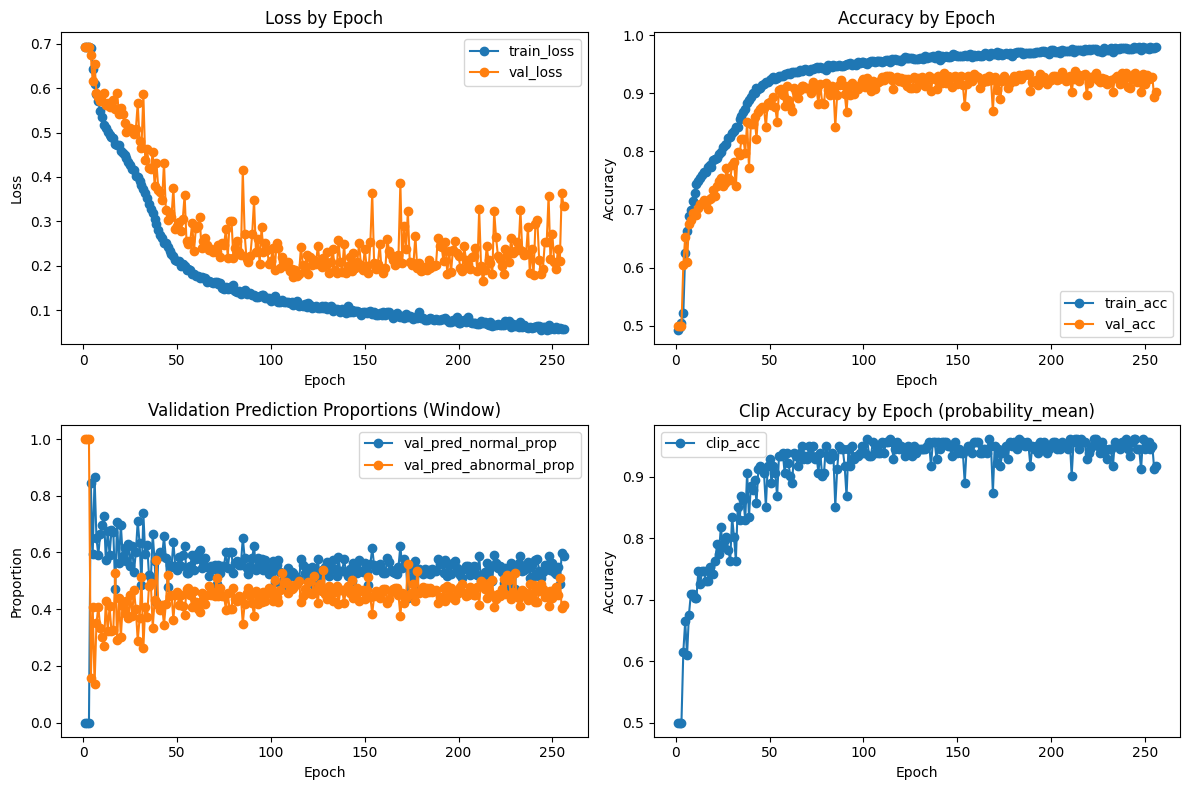

Interpretation category: C. Pipeline works, meaningful signal emerging
normal_recall=0.9890, abnormal_recall=0.8150, val_acc=0.9020


In [6]:
def _evaluate_loader(loader, expect_clip_id: bool = False):
    model.eval()
    y_true = []
    y_pred = []
    loss_sum = 0.0
    count = 0
    window_records = []

    with torch.no_grad():
        for batch in loader:
            if expect_clip_id:
                if len(batch) != 3:
                    raise RuntimeError('Expected loader batch to be (x, y, clip_id).')
                x, y, clip_ids = batch
            else:
                if len(batch) == 2:
                    x, y = batch
                    clip_ids = None
                elif len(batch) == 3:
                    x, y, clip_ids = batch
                else:
                    raise RuntimeError(f'Unexpected batch structure (len={len(batch)}).')

            x = x.to(runtime_device, non_blocking=True)
            y = y.to(runtime_device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            preds = torch.argmax(logits, dim=1)
            probs = torch.softmax(logits, dim=1)
            abnormal_probs = probs[:, 1]

            y_cpu = y.detach().cpu().numpy().tolist()
            pred_cpu = preds.detach().cpu().numpy().tolist()

            y_true.extend(y_cpu)
            y_pred.extend(pred_cpu)
            loss_sum += float(loss.item()) * x.size(0)
            count += int(x.size(0))

            if expect_clip_id:
                clip_ids_list = [str(c) for c in clip_ids]
                abnormal_probs_cpu = abnormal_probs.detach().cpu().numpy().tolist()
                if len(clip_ids_list) != len(y_cpu):
                    raise RuntimeError(
                        f'clip_id batch size mismatch during evaluation: clip_ids={len(clip_ids_list)}, labels={len(y_cpu)}'
                    )

                for clip_id_item, true_label_item, pred_item, abnormal_prob_item in zip(
                    clip_ids_list,
                    y_cpu,
                    pred_cpu,
                    abnormal_probs_cpu,
                ):
                    clip_id_clean = str(clip_id_item).strip()
                    if not clip_id_clean or clip_id_clean.lower() == 'nan':
                        raise RuntimeError('clip_id exists check failed during evaluation.')
                    window_records.append(
                        {
                            'clip_id': clip_id_clean,
                            'true_label': int(true_label_item),
                            'pred_class': int(pred_item),
                            'abnormal_prob': float(abnormal_prob_item),
                        }
                    )

    return (
        np.asarray(y_true, dtype=np.int64),
        np.asarray(y_pred, dtype=np.int64),
        (loss_sum / max(1, count)),
        window_records,
    )


if history['epoch']:
    final_train_loss = history['train_loss'][-1]
    final_val_loss_from_epoch = history['val_loss'][-1]
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]
else:
    final_train_loss = float('nan')
    final_val_loss_from_epoch = float('nan')
    final_train_acc = float('nan')
    final_val_acc = float('nan')

val_y_true, val_y_pred, eval_val_loss, val_eval_window_records = _evaluate_loader(val_loader, expect_clip_id=True)
train_y_true, train_y_pred, eval_train_loss, _ = _evaluate_loader(train_loader, expect_clip_id=False)

cm = _confusion_matrix_binary(val_y_true, val_y_pred)
confusion_df = pd.DataFrame(
    cm,
    index=['true_normal', 'true_abnormal'],
    columns=['pred_normal', 'pred_abnormal'],
)
CHECKS['confusion matrix generated'] = True

pred_normal = int((val_y_pred == 0).sum())
pred_abnormal = int((val_y_pred == 1).sum())
pred_total = int(len(val_y_pred))
pred_normal_prop = pred_normal / pred_total if pred_total else 0.0
pred_abnormal_prop = pred_abnormal / pred_total if pred_total else 0.0
CHECKS['prediction distribution computed'] = True

clip_eval_metrics = _compute_clip_level_metrics_from_records(
    val_eval_window_records,
    aggregation_method=clip_aggregation_method,
    include_report=True,
)
clip_summary_df = clip_eval_metrics['per_clip_summary_df'].copy()
clip_cm = clip_eval_metrics['clip_confusion_matrix']
clip_confusion_df = pd.DataFrame(
    clip_cm,
    index=['true_normal', 'true_abnormal'],
    columns=['pred_normal', 'pred_abnormal'],
)
clip_count = int(clip_eval_metrics['clip_count'])
clip_accuracy = float(clip_eval_metrics['clip_accuracy'])
clip_pred_normal = int(clip_eval_metrics['clip_pred_normal'])
clip_pred_abnormal = int(clip_eval_metrics['clip_pred_abnormal'])
clip_pred_normal_prop = float(clip_eval_metrics['clip_pred_normal_prop'])
clip_pred_abnormal_prop = float(clip_eval_metrics['clip_pred_abnormal_prop'])
clip_classification_report_text = clip_eval_metrics['clip_classification_report_text']
clip_classification_report_dict = clip_eval_metrics['clip_classification_report_dict']

CHECKS['clip-level metrics computed'] = True

print('final train loss:', final_train_loss)
print('final validation loss:', final_val_loss_from_epoch)
print('final train accuracy:', final_train_acc)
print('final validation accuracy:', final_val_acc)
print('evaluation train loss:', eval_train_loss)
print('evaluation validation loss:', eval_val_loss)
print('confusion matrix:')
display(confusion_df)
print('prediction distribution on validation set:')
print(f'predicted normal={pred_normal}, predicted abnormal={pred_abnormal}')
print(f'predicted normal proportion={pred_normal_prop:.4f}, predicted abnormal proportion={pred_abnormal_prop:.4f}')

print('clip-level report (validation):')
print(f'clip_aggregation_method={clip_aggregation_method}')
print(f'clip_count={clip_count}')
print(f'clip_accuracy={clip_accuracy:.4f}')
print('clip_confusion_matrix:')
display(clip_confusion_df)
print(f'predicted normal clips={clip_pred_normal}, predicted abnormal clips={clip_pred_abnormal}')
print(
    f'predicted normal clip proportion={clip_pred_normal_prop:.4f}, '
    f'predicted abnormal clip proportion={clip_pred_abnormal_prop:.4f}'
)
print(
    f'clip_accuracy(probability_mean)={clip_eval_metrics["probability_mean_accuracy"]:.4f}, '
    f'clip_accuracy(majority_vote)={clip_eval_metrics["majority_vote_accuracy"]:.4f}'
)

classification_report_text = None
classification_report_dict = None
if SKLEARN_AVAILABLE:
    print('classification report (validation windows):')
    classification_report_text = classification_report(
        val_y_true,
        val_y_pred,
        labels=[0, 1],
        target_names=['normal', 'abnormal'],
        digits=4,
        zero_division=0,
    )
    print(classification_report_text)
    classification_report_dict = classification_report(
        val_y_true,
        val_y_pred,
        labels=[0, 1],
        target_names=['normal', 'abnormal'],
        output_dict=True,
        zero_division=0,
    )

    print('classification report (validation clips):')
    if clip_classification_report_text is not None:
        print(clip_classification_report_text)
else:
    print('sklearn.metrics not available; skipping classification reports.')

history_df = pd.DataFrame(history)
display(history_df.tail(min(10, len(history_df))))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(history['epoch'], history['train_loss'], marker='o', label='train_loss')
axes[0, 0].plot(history['epoch'], history['val_loss'], marker='o', label='val_loss')
axes[0, 0].set_title('Loss by Epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].plot(history['epoch'], history['train_acc'], marker='o', label='train_acc')
axes[0, 1].plot(history['epoch'], history['val_acc'], marker='o', label='val_acc')
axes[0, 1].set_title('Accuracy by Epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

axes[1, 0].plot(history['epoch'], history['val_pred_normal_prop'], marker='o', label='val_pred_normal_prop')
axes[1, 0].plot(history['epoch'], history['val_pred_abnormal_prop'], marker='o', label='val_pred_abnormal_prop')
axes[1, 0].set_title('Validation Prediction Proportions (Window)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].legend()

axes[1, 1].plot(history['epoch'], history['clip_acc'], marker='o', label='clip_acc')
axes[1, 1].set_title(f'Clip Accuracy by Epoch ({clip_aggregation_method})')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

fig.tight_layout()
plt.show()
CHECKS['history plots generated'] = True

tn, fp = int(cm[0, 0]), int(cm[0, 1])
fn, tp = int(cm[1, 0]), int(cm[1, 1])

normal_recall = tn / (tn + fp) if (tn + fp) else 0.0
abnormal_recall = tp / (tp + fn) if (tp + fn) else 0.0

collapse_detected = (pred_normal == 0 or pred_abnormal == 0 or max(pred_normal_prop, pred_abnormal_prop) >= 0.95)

if collapse_detected:
    interpretation_category = 'A. Pipeline works, model still collapses'
elif final_val_acc >= 0.65 and normal_recall > 0.0 and abnormal_recall > 0.0:
    interpretation_category = 'C. Pipeline works, meaningful signal emerging'
elif final_val_acc > 0.50 and normal_recall > 0.0 and abnormal_recall > 0.0:
    interpretation_category = 'B. Pipeline works, weak but nontrivial signal'
else:
    interpretation_category = 'A. Pipeline works, model still collapses'

final_metrics = {
    'final_train_loss': float(final_train_loss),
    'final_val_loss_from_epoch': float(final_val_loss_from_epoch),
    'eval_train_loss': float(eval_train_loss),
    'eval_val_loss': float(eval_val_loss),
    'final_train_accuracy': float(final_train_acc),
    'final_val_accuracy': float(final_val_acc),
    'pred_normal_count': int(pred_normal),
    'pred_abnormal_count': int(pred_abnormal),
    'pred_normal_prop': float(pred_normal_prop),
    'pred_abnormal_prop': float(pred_abnormal_prop),
    'normal_recall': float(normal_recall),
    'abnormal_recall': float(abnormal_recall),
    'collapse_detected': bool(collapse_detected),
    'best_epoch': int(best_epoch) if best_epoch is not None else None,
    'best_val_loss': float(best_val_loss) if best_val_loss != float('inf') else None,
    'best_clip_acc': float(best_clip_acc) if best_clip_acc is not None else None,
    'clip_aggregation_method': clip_aggregation_method,
    'clip_count': int(clip_count),
    'clip_accuracy': float(clip_accuracy),
    'clip_pred_normal_count': int(clip_pred_normal),
    'clip_pred_abnormal_count': int(clip_pred_abnormal),
    'clip_pred_normal_prop': float(clip_pred_normal_prop),
    'clip_pred_abnormal_prop': float(clip_pred_abnormal_prop),
    'clip_accuracy_probability_mean': float(clip_eval_metrics['probability_mean_accuracy']),
    'clip_accuracy_majority_vote': float(clip_eval_metrics['majority_vote_accuracy']),
}

print('Interpretation category:', interpretation_category)
print(f'normal_recall={normal_recall:.4f}, abnormal_recall={abnormal_recall:.4f}, val_acc={final_val_acc:.4f}')


## 7. Artifact writeout


In [7]:
def _run_git_command(args):
    try:
        result = subprocess.run(
            ['git', *args],
            cwd=REPO_ROOT,
            check=False,
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            return None
        return result.stdout.strip()
    except Exception:
        return None


def _git_info():
    status_short = _run_git_command(['status', '--short'])
    return {
        'git_commit': _run_git_command(['rev-parse', 'HEAD']),
        'git_branch': _run_git_command(['rev-parse', '--abbrev-ref', 'HEAD']),
        'dirty_worktree': bool(status_short),
        'git_status_short': status_short.splitlines() if status_short else [],
    }


run_timestamp = datetime.now().strftime('%Y%m%d-%H%M')
run_notebook_stem = NOTEBOOK_RELATIVE_PATH.stem
MODEL_OUTPUT_DIR = models_root / f'{run_timestamp}-{run_notebook_stem}'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = MODEL_OUTPUT_DIR / 'final_model_state_dict.pt'
BEST_MODEL_PATH = MODEL_OUTPUT_DIR / 'best_val_model_state_dict.pt'
TRAINING_HISTORY_JSON_PATH = MODEL_OUTPUT_DIR / 'training_history.json'
METRICS_JSON_PATH = MODEL_OUTPUT_DIR / 'metrics.json'
RUN_MANIFEST_JSON_PATH = MODEL_OUTPUT_DIR / 'run_manifest.json'
SPLIT_MEMBERSHIP_PATH = MODEL_OUTPUT_DIR / 'split_membership.csv'
CLIP_LEVEL_SUMMARY_CSV_PATH = MODEL_OUTPUT_DIR / 'clip_level_predictions.csv'
CLIP_LEVEL_SUMMARY_JSON_PATH = MODEL_OUTPUT_DIR / 'clip_level_predictions.json'
MODEL_CARD_PATH = MODEL_OUTPUT_DIR / 'model_card.md'

local_artifacts = {}
if save_local_checkpoints:
    final_checkpoint = {
        'model_state_dict': model.state_dict(),
        'input_mode': input_mode,
        'epoch_count_ran': len(history['epoch']),
        'random_seed': random_seed,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'device': str(runtime_device),
    }
    torch.save(final_checkpoint, FINAL_MODEL_PATH)

    if best_state_dict is None:
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = history['epoch'][-1] if history['epoch'] else None

    best_checkpoint = {
        'model_state_dict': best_state_dict,
        'best_val_loss': float(best_val_loss) if best_val_loss != float('inf') else None,
        'best_epoch': int(best_epoch) if best_epoch is not None else None,
        'best_clip_acc': float(best_clip_acc) if best_clip_acc is not None else None,
        'best_clip_metrics': best_clip_metrics,
        'input_mode': input_mode,
        'random_seed': random_seed,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'device': str(runtime_device),
    }
    torch.save(best_checkpoint, BEST_MODEL_PATH)

    local_artifacts = {
        'final_checkpoint_local_only': repo_rel(FINAL_MODEL_PATH),
        'best_val_checkpoint_local_only': repo_rel(BEST_MODEL_PATH),
    }

split_membership_df.to_csv(SPLIT_MEMBERSHIP_PATH, index=False)
CHECKS['split membership saved'] = True

clip_summary_df.to_csv(CLIP_LEVEL_SUMMARY_CSV_PATH, index=False)
clip_summary_records = json.loads(clip_summary_df.to_json(orient='records'))
CLIP_LEVEL_SUMMARY_JSON_PATH.write_text(json.dumps(clip_summary_records, indent=2))
CHECKS['clip-level artifacts saved'] = True

metrics_payload = {
    'run_id': MODEL_OUTPUT_DIR.name,
    'notebook': repo_rel(NOTEBOOK_PATH),
    'input_mode': input_mode,
    'machine_filter': machine_filter,
    'final_metrics': final_metrics,
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report_dict,
    'clip_aggregation_method': clip_aggregation_method,
    'clip_confusion_matrix': clip_cm.tolist(),
    'clip_classification_report': clip_classification_report_dict,
    'clip_summary_csv_path': repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH),
    'clip_summary_json_path': repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH),
    'interpretation_category': interpretation_category,
}
METRICS_JSON_PATH.write_text(json.dumps(metrics_payload, indent=2))
CHECKS['metrics artifact saved'] = True

history_payload = {
    'run_id': MODEL_OUTPUT_DIR.name,
    'notebook': repo_rel(NOTEBOOK_PATH),
    'input_mode': input_mode,
    'machine_filter': machine_filter,
    'random_seed': random_seed,
    'window_manifest_paths': [repo_rel(p) for p in window_manifest_paths],
    'clip_manifest_paths': [repo_rel(p) for p in clip_manifest_paths],
    'preprocessing_config_paths': [repo_rel(p) for p in preprocessing_config_paths],
    'hyperparameters': {
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'learning_rate': learning_rate,
        'device': str(runtime_device),
        'val_fraction': val_fraction,
        'deterministic_training': deterministic_training,
        'clip_aggregation_method': clip_aggregation_method,
    },
    'subset_summary': {
        'selected_normal_clips': int(len(selected_normal_df)),
        'selected_abnormal_clips': int(len(selected_abnormal_df)),
        'train_normal_clips': int(train_normal_clips),
        'train_abnormal_clips': int(train_abnormal_clips),
        'val_normal_clips': int(val_normal_clips),
        'val_abnormal_clips': int(val_abnormal_clips),
        'train_normal_windows': int(train_normal_windows),
        'train_abnormal_windows': int(train_abnormal_windows),
        'val_normal_windows': int(val_normal_windows),
        'val_abnormal_windows': int(val_abnormal_windows),
    },
    'split_artifact_path': repo_rel(SPLIT_MEMBERSHIP_PATH),
    'history': history,
    'final_metrics': final_metrics,
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report_dict,
    'clip_confusion_matrix': clip_cm.tolist(),
    'clip_classification_report': clip_classification_report_dict,
    'clip_summary_csv_path': repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH),
    'clip_summary_json_path': repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH),
    'interpretation_category': interpretation_category,
    'checklist': CHECKS,
}
TRAINING_HISTORY_JSON_PATH.write_text(json.dumps(history_payload, indent=2))

git_info = _git_info()
environment_summary = {
    'python_version': platform.python_version(),
    'torch_version': getattr(torch, '__version__', None),
    'torchaudio_version': getattr(torchaudio, '__version__', None) if torchaudio is not None else None,
    'numpy_version': getattr(np, '__version__', None),
    'pandas_version': getattr(pd, '__version__', None),
    'pyarrow_version': getattr(pyarrow, '__version__', None) if pyarrow is not None else None,
    'cuda_version': getattr(torch.version, 'cuda', None),
    'device': str(runtime_device),
    'deterministic_training': bool(deterministic_training),
    'requirements_path': repo_rel(REPO_ROOT / 'requirements.txt'),
    'requirements_sha256': sha256_file(REPO_ROOT / 'requirements.txt'),
}

source_manifest_paths = [*window_manifest_paths, *clip_manifest_paths]
source_manifest_sha256 = {repo_rel(p): sha256_file(p) for p in source_manifest_paths}
preprocessing_config_sha256 = {repo_rel(p): sha256_file(p) for p in preprocessing_config_paths}

run_manifest = {
    'run_id': MODEL_OUTPUT_DIR.name,
    'created_utc': utc_now_iso(),
    'git_commit': git_info['git_commit'],
    'git_branch': git_info['git_branch'],
    'dirty_worktree': git_info['dirty_worktree'],
    'git_status_short': git_info['git_status_short'],
    'entrypoint_type': 'notebook',
    'entrypoint_path': repo_rel(NOTEBOOK_PATH),
    'entrypoint_sha256': sha256_file(NOTEBOOK_PATH),
    'source_manifest_paths': [repo_rel(p) for p in source_manifest_paths],
    'source_manifest_sha256': source_manifest_sha256,
    'window_manifest_paths': [repo_rel(p) for p in window_manifest_paths],
    'clip_manifest_paths': [repo_rel(p) for p in clip_manifest_paths],
    'preprocessing_config_paths': [repo_rel(p) for p in preprocessing_config_paths],
    'preprocessing_config_sha256': preprocessing_config_sha256,
    'dataset_summary': {
        'machine_filter': machine_filter,
        'selected_normal_clips': int(len(selected_normal_df)),
        'selected_abnormal_clips': int(len(selected_abnormal_df)),
        'train_clip_ids': sorted([str(x) for x in train_clip_ids]),
        'val_clip_ids': sorted([str(x) for x in val_clip_ids]),
        'split_artifact_path': repo_rel(SPLIT_MEMBERSHIP_PATH),
    },
    'model_name': 'Baseline2DCNN',
    'model_architecture_summary': (
        'Conv2d(2->16,k5)+ReLU+MaxPool -> Conv2d(16->32,k3)+ReLU+MaxPool -> '
        'Conv2d(32->64,k3)+ReLU+MaxPool -> AdaptiveAvgPool2d(1,1) -> Linear(64->2)'
    ),
    'input_representation': input_mode,
    'input_shape': [2, 96, 64],
    'optimizer': 'Adam',
    'loss_function': 'CrossEntropyLoss',
    'hyperparameters': {
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'learning_rate': learning_rate,
        'val_fraction': val_fraction,
        'match_normal_to_abnormal_when_abnormal_limited': match_normal_to_abnormal_when_abnormal_limited,
        'clip_aggregation_method': clip_aggregation_method,
    },
    'random_seeds': {
        'python_random': random_seed,
        'numpy': random_seed,
        'torch': random_seed,
        'torch_cuda_manual_seed_all': random_seed if torch.cuda.is_available() else None,
    },
    'environment': environment_summary,
    'artifact_paths': {
        'training_history': repo_rel(TRAINING_HISTORY_JSON_PATH),
        'metrics': repo_rel(METRICS_JSON_PATH),
        'split_membership': repo_rel(SPLIT_MEMBERSHIP_PATH),
        'clip_level_summary_csv': repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH),
        'clip_level_summary_json': repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH),
        'model_card': repo_rel(MODEL_CARD_PATH),
        **local_artifacts,
    },
    'change_note': change_note,
}
RUN_MANIFEST_JSON_PATH.write_text(json.dumps(run_manifest, indent=2))
CHECKS['run manifest saved'] = True

model_card = f"""# Model Card (Brief)

## Notebook
- Category: `training`
- Source notebook: `{repo_rel(NOTEBOOK_PATH)}`
- Notebook SHA256: `{sha256_file(NOTEBOOK_PATH)}`

## Model
- Name: `Baseline2DCNN`
- Architecture: Conv2d(2->16, k5) + ReLU + MaxPool, Conv2d(16->32, k3) + ReLU + MaxPool, Conv2d(32->64, k3) + ReLU + MaxPool, AdaptiveAvgPool2d(1,1), Linear(64->2)

## Task
- Binary machine-sound classification on pump clips
- Labels: `normal=0`, `abnormal=1`

## Inputs
- Window manifests: `{', '.join(repo_rel(p) for p in window_manifest_paths)}`
- Clip manifests: `{', '.join(repo_rel(p) for p in clip_manifest_paths)}`
- Preprocessing configs: `{', '.join(repo_rel(p) for p in preprocessing_config_paths)}`
- Base representation: `normalized_window` shape `(96, 64)` and `active_mask` shape `(96, 64)`
- Input mode: `{input_mode}`
- Final tensor shape: `(2, 96, 64)`
- Clip-level split only (no window-level random split)

## Data & Split
- Selected clips: normal={len(selected_normal_df)}, abnormal={len(selected_abnormal_df)}
- Train clips: normal={train_normal_clips}, abnormal={train_abnormal_clips}
- Validation clips: normal={val_normal_clips}, abnormal={val_abnormal_clips}
- Train windows: normal={train_normal_windows}, abnormal={train_abnormal_windows}
- Validation windows: normal={val_normal_windows}, abnormal={val_abnormal_windows}
- Exact split membership: `{repo_rel(SPLIT_MEMBERSHIP_PATH)}`

## Training
- Epochs configured: {num_epochs}
- Epochs completed: {len(history['epoch'])}
- Batch size: {batch_size}
- Learning rate: {learning_rate}
- Device: {runtime_device}
- Random seed: {random_seed}
- Deterministic training flag: {deterministic_training}

## Results (This Run)
- Final train accuracy: {final_train_acc:.4f}
- Final validation accuracy (window): {final_val_acc:.4f}
- Final validation loss: {final_val_loss_from_epoch:.4f}
- Predicted distribution (window val): normal={pred_normal} ({pred_normal_prop:.4f}), abnormal={pred_abnormal} ({pred_abnormal_prop:.4f})
- Clip aggregation method: {clip_aggregation_method}
- Clip validation accuracy: {clip_accuracy:.4f}
- Predicted distribution (clip val): normal={clip_pred_normal} ({clip_pred_normal_prop:.4f}), abnormal={clip_pred_abnormal} ({clip_pred_abnormal_prop:.4f})
- Interpretation: {interpretation_category}
- Metrics JSON: `{repo_rel(METRICS_JSON_PATH)}`
- Run manifest: `{repo_rel(RUN_MANIFEST_JSON_PATH)}`

## Artifact Tracking
- Git-tracked artifacts:
  - `{repo_rel(TRAINING_HISTORY_JSON_PATH)}`
  - `{repo_rel(METRICS_JSON_PATH)}`
  - `{repo_rel(SPLIT_MEMBERSHIP_PATH)}`
  - `{repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH)}`
  - `{repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH)}`
  - `{repo_rel(RUN_MANIFEST_JSON_PATH)}`
  - `{repo_rel(MODEL_CARD_PATH)}`
- Local-only artifacts intentionally excluded from Git by `.gitignore`:
  - `{repo_rel(FINAL_MODEL_PATH) if save_local_checkpoints else 'not written'}`
  - `{repo_rel(BEST_MODEL_PATH) if save_local_checkpoints else 'not written'}`
"""
MODEL_CARD_PATH.write_text(model_card)
CHECKS['model artifacts saved'] = True

print('Saved tracked artifacts to:', repo_rel(MODEL_OUTPUT_DIR))
print(' -', repo_rel(TRAINING_HISTORY_JSON_PATH))
print(' -', repo_rel(METRICS_JSON_PATH))
print(' -', repo_rel(SPLIT_MEMBERSHIP_PATH))
print(' -', repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH))
print(' -', repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH))
print(' -', repo_rel(RUN_MANIFEST_JSON_PATH))
print(' -', repo_rel(MODEL_CARD_PATH))
if save_local_checkpoints:
    print('Local-only checkpoints:')
    print(' -', repo_rel(FINAL_MODEL_PATH))
    print(' -', repo_rel(BEST_MODEL_PATH))


Saved tracked artifacts to: models/20260320-2201-2d_sound_v0.5
 - models/20260320-2201-2d_sound_v0.5/training_history.json
 - models/20260320-2201-2d_sound_v0.5/metrics.json
 - models/20260320-2201-2d_sound_v0.5/split_membership.csv
 - models/20260320-2201-2d_sound_v0.5/clip_level_predictions.csv
 - models/20260320-2201-2d_sound_v0.5/clip_level_predictions.json
 - models/20260320-2201-2d_sound_v0.5/run_manifest.json
 - models/20260320-2201-2d_sound_v0.5/model_card.md
Local-only checkpoints:
 - models/20260320-2201-2d_sound_v0.5/final_model_state_dict.pt
 - models/20260320-2201-2d_sound_v0.5/best_val_model_state_dict.pt


## 8. Final verdict


In [8]:
print('PASS / READY')
pass_items = [k for k, v in CHECKS.items() if v]
if pass_items:
    for item in pass_items:
        print(f'- {item}')
else:
    print('- none')

print('')
print('FAIL / PATCH REQUIRED')
fail_items = [k for k, v in CHECKS.items() if not v]
if fail_items:
    for item in fail_items:
        print(f'- {item}')
else:
    print('- none')

if NAN_DETECTED:
    print('- NaN detected during training/evaluation')
if TRAINING_EXCEPTION is not None:
    print(f'- training_exception: {type(TRAINING_EXCEPTION).__name__}: {TRAINING_EXCEPTION}')

final_machine_verdict = 'READY_FOR_NEXT_DECISION' if (not fail_items and not NAN_DETECTED and TRAINING_EXCEPTION is None) else 'PATCH_REQUIRED'
print('')
print('FINAL_VERDICT:', final_machine_verdict)
print(final_machine_verdict)


PASS / READY
- manifests loaded
- clip-level split applied
- split diagnostics printed
- dataset loader works
- training completed
- prediction distribution computed
- confusion matrix generated
- clip-level metrics computed
- history plots generated
- split membership saved
- metrics artifact saved
- clip-level artifacts saved
- run manifest saved
- model artifacts saved

FAIL / PATCH REQUIRED
- none

FINAL_VERDICT: READY_FOR_NEXT_DECISION
READY_FOR_NEXT_DECISION
